# 04. Weighted Deeper BatchNorm CNN for Melanoma Classification

**Objective**  
Extend the weighted BatchNorm CNN by increasing model depth and feature extraction capacity. This notebook tests whether a deeper custom CNN can improve lesion representation and overall performance while still using class-weighted loss to emphasize melanoma detection.

**Model Architecture**

| Stage | Layers |
| --- | --- |
| Input | RGB dermoscopic image |
| Block 1 | `Conv2d -> BatchNorm2d -> ReLU -> Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d` |
| Block 2 | `Conv2d -> BatchNorm2d -> ReLU -> Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d` |
| Block 3 | `Conv2d -> BatchNorm2d -> ReLU -> Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d` |
| Block 4 | `Conv2d -> BatchNorm2d -> ReLU -> Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d` |
| Head | `AdaptiveAvgPool2d(1,1) -> Flatten -> Linear -> ReLU -> Dropout -> Linear` |

Compared with Notebook 03, this version keeps the same weighted training and threshold-tuning pipeline but uses a deeper convolutional backbone to learn richer image features.

### 1. Setup and Imports

This section loads the project modules, trainer utilities, and shared evaluation helpers, then selects the available compute device (`CUDA`, `MPS`, or `CPU`).  
The deeper CNN is defined directly in this notebook so the experiment is self-contained.

In [ ]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.cnn_batchnorm_deeper import DeeperBatchNormCNN
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


### 2. Data Split and Weighted-Loss Configuration

The dataset is loaded using the predefined train, validation, and test CSV splits.  
This experiment replaces the previous BatchNorm CNN with `DeeperBatchNormCNN`, while keeping weighted BCE loss to address class imbalance:

- `DeeperBatchNormCNN` as the feature extractor and classifier
- `BCEWithLogitsLoss(pos_weight=...)` to penalize missed melanoma more strongly
- `Adam` with learning rate `1e-3`
- Batch size `32` and image size `224 x 224`

The positive-class weight is computed directly from class imbalance:

`pos_weight = number_of_nevus / number_of_melanoma`

In [5]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / "data_new/splits/train.csv"),
    val_csv=str(ROOT / "data_new/splits/val.csv"),
    test_csv=str(ROOT / "data_new/splits/test.csv"),
    image_dir=str(ROOT / "data_new/images/train"),
    test_image_dir=str(ROOT / "data_new/images/test"),
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv(ROOT / "data_new/splits/train.csv")

num_melanoma = (train_df["label"] == 1).sum()
num_nevus = (train_df["label"] == 0).sum()
pos_weight_value = num_nevus / num_melanoma

print(f"Training samples: {len(train_df)}")
print(f"Melanoma: {num_melanoma}")
print(f"Nevus: {num_nevus}")
print(f"pos_weight: {pos_weight_value:.4f}")

model = DeeperBatchNormCNN(num_classes=1).to(device)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Training samples: 7991
Melanoma: 877
Nevus: 7114
pos_weight: 8.1117


### 3. Train the Weighted Deeper BatchNorm Model

The model is trained for `20` epochs using the deeper CNN with weighted BCE loss.  
Training and validation metrics are stored as lists of dictionaries so they can be passed directly into the shared plotting function later. The checkpoint with the highest validation AUC is saved.

In [6]:
num_epochs = 20

best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
          f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
          f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/cnn_deeper_batchnorm_weighted.pth')
        print("  Saved best model.")

Epoch [1/20]
  Train | Loss: 1.0079, Bal Acc: 0.6944, Recall: 0.8324, F2: 0.4937, AUC: 0.7593
  Val   | Loss: 1.0368, Bal Acc: 0.6900, Recall: 0.5254, F2: 0.4669, AUC: 0.8054
  Saved best model.


Epoch [2/20]
  Train | Loss: 0.9663, Bal Acc: 0.7237, Recall: 0.8506, F2: 0.5237, AUC: 0.7849
  Val   | Loss: 1.1819, Bal Acc: 0.6773, Recall: 0.5297, F2: 0.4522, AUC: 0.7856


Epoch [3/20]
  Train | Loss: 0.9544, Bal Acc: 0.7239, Recall: 0.8495, F2: 0.5238, AUC: 0.7873
  Val   | Loss: 0.9262, Bal Acc: 0.7503, Recall: 0.8686, F2: 0.5672, AUC: 0.8298
  Saved best model.


Epoch [4/20]
  Train | Loss: 0.9216, Bal Acc: 0.7425, Recall: 0.8483, F2: 0.5441, AUC: 0.8072
  Val   | Loss: 1.0061, Bal Acc: 0.7015, Recall: 0.6229, F2: 0.4953, AUC: 0.8082


Epoch [5/20]
  Train | Loss: 0.8965, Bal Acc: 0.7499, Recall: 0.8632, F2: 0.5526, AUC: 0.8191
  Val   | Loss: 0.8985, Bal Acc: 0.7533, Recall: 0.8136, F2: 0.5697, AUC: 0.8389
  Saved best model.


...

Epoch [16/20]
  Train | Loss: 0.7925, Bal Acc: 0.7893, Recall: 0.8734, F2: 0.6011, AUC: 0.8673
  Val   | Loss: 0.8262, Bal Acc: 0.7832, Recall: 0.8517, F2: 0.6073, AUC: 0.8626


Epoch [17/20]
  Train | Loss: 0.7802, Bal Acc: 0.7914, Recall: 0.8826, F2: 0.6033, AUC: 0.8679
  Val   | Loss: 0.8472, Bal Acc: 0.7846, Recall: 0.8814, F2: 0.6082, AUC: 0.8621


Epoch [18/20]
  Train | Loss: 0.7920, Bal Acc: 0.7889, Recall: 0.8757, F2: 0.6004, AUC: 0.8665
  Val   | Loss: 0.8194, Bal Acc: 0.7789, Recall: 0.8559, F2: 0.6015, AUC: 0.8684


Epoch [19/20]
  Train | Loss: 0.7795, Bal Acc: 0.7921, Recall: 0.8826, F2: 0.6042, AUC: 0.8683
  Val   | Loss: 0.8137, Bal Acc: 0.7742, Recall: 0.8644, F2: 0.5954, AUC: 0.8666


Epoch [20/20]
  Train | Loss: 0.7914, Bal Acc: 0.7804, Recall: 0.8883, F2: 0.5887, AUC: 0.8623
  Val   | Loss: 0.8351, Bal Acc: 0.7626, Recall: 0.9195, F2: 0.5815, AUC: 0.8659


### 4. Plot Training Curves

This notebook uses the shared evaluation utility to render the standard 2 × 2 dashboard: Loss, Balanced Accuracy, Recall, and F2.  
This keeps the deeper CNN experiment directly comparable with the earlier CNN notebooks.

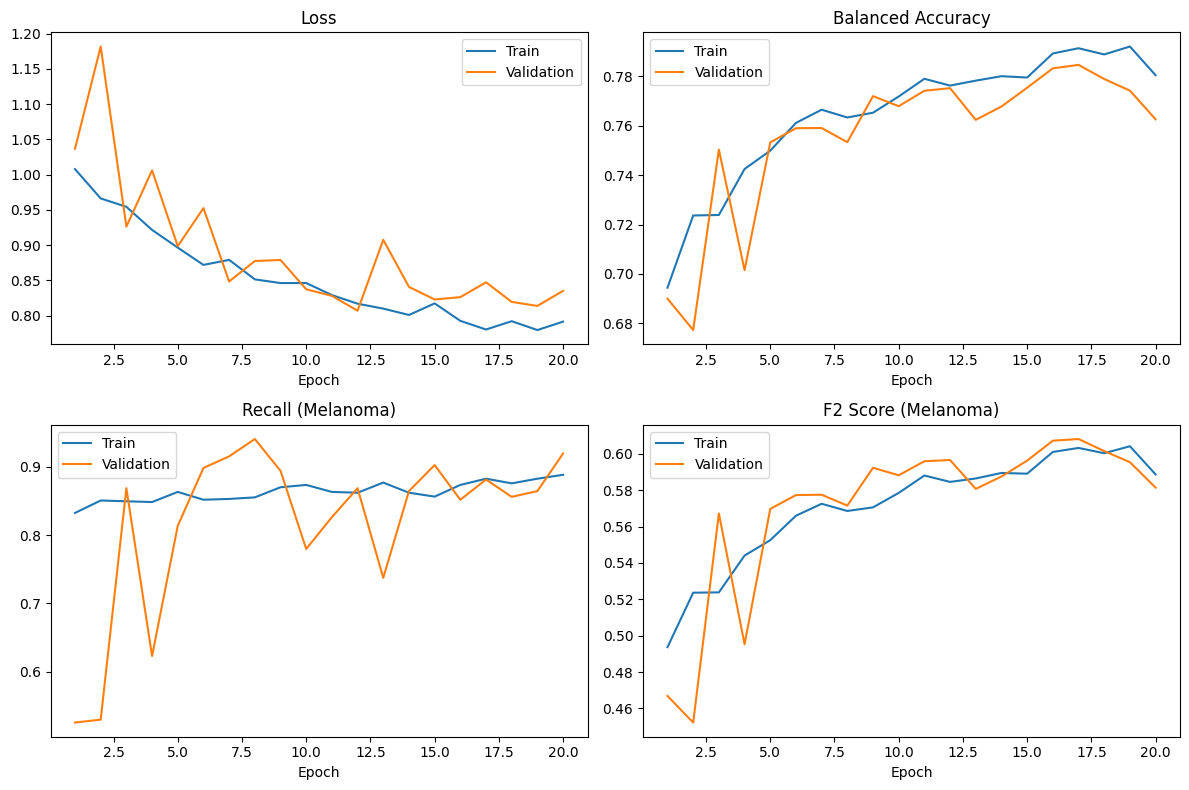

In [7]:
plot_training_curves(train_history, val_history)

### 5. Tune the Classification Threshold on the Validation Set

The loss is weighted during training, but the classification threshold still needs to be chosen separately.  
This step reloads the best saved checkpoint and finds the probability threshold that maximizes **F2 score** on the validation set.

In [8]:
model.load_state_dict(torch.load(ROOT / 'models/cnn_deeper_batchnorm_weighted.pth', map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Best validation F2: {best_f2:.4f}")

Best threshold: 0.66 | Val F2: 0.6122
Best validation threshold: 0.66
Best validation F2: 0.6122


### 6. Evaluate on the Test Set

The best deeper weighted checkpoint is evaluated on the held-out test set using the threshold selected on the validation set.  
The shared evaluation utility reports AUC-ROC, balanced accuracy, F2 score, a classification report, and visual diagnostics such as the confusion matrix and ROC curve.

Threshold:          0.66
AUC-ROC:            0.8538
Balanced Accuracy:  0.7456
F2 Score:           0.5525

              precision    recall  f1-score   support

Non-Melanoma     0.9545    0.7836    0.8607      1340
    Melanoma     0.2944    0.7076    0.4158       171

    accuracy                         0.7750      1511
   macro avg     0.6245    0.7456    0.6382      1511
weighted avg     0.8798    0.7750    0.8103      1511



/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


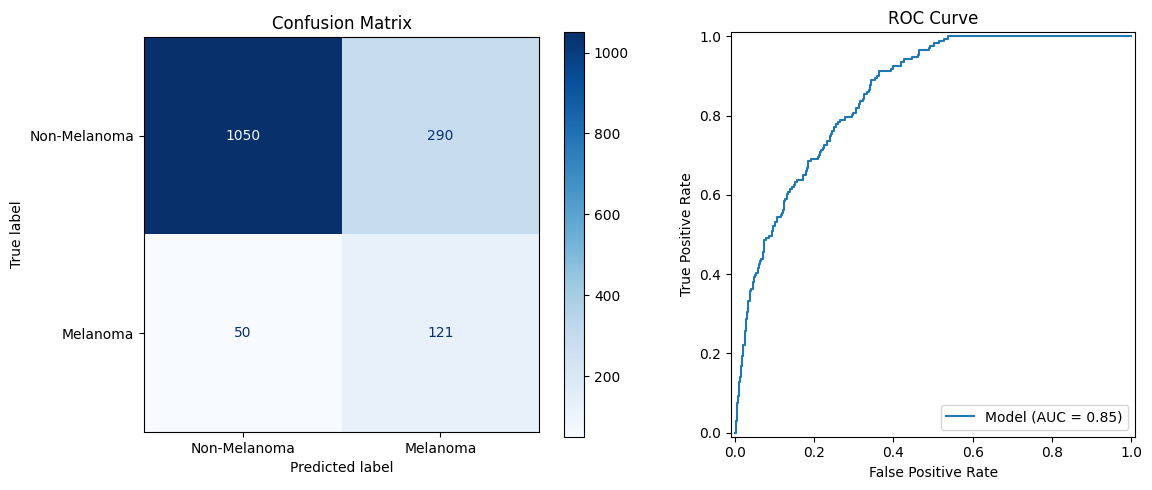

In [9]:
evaluate_model(model, test_loader, device, threshold=best_threshold)

### Results Summary (Deeper BatchNorm CNN)

**Performance**
- AUC slightly increases (0.8520 → 0.8538)
- Balanced Accuracy decreases (0.7735 → 0.7456)
- F2 Score decreases (0.5900 → 0.5525)

**Class-wise Behavior**
- Melanoma recall drops significantly (0.7895 → 0.7076)
- Melanoma precision remains almost unchanged (~0.29)
- Model detects fewer melanoma cases → worse sensitivity

**Training Behavior**
- Training remains stable with BatchNorm
- No signs of overfitting (train and validation aligned)
- However, performance plateaus without meaningful gain

**Comparison to Previous Model**
- Deeper CNN does NOT improve performance
- Slight AUC gain does not translate to better classification
- Key metrics (F2, recall, balanced accuracy) are worse

**Conclusion**
- Increasing depth alone does not improve performance
- Model becomes more conservative without improving precision
- Feature representation is still insufficient